This notebook takes an observation and check which satellites will be / are present in that observation.

In [40]:
import numpy as np
import pickle
from astropy import units as u
from skyfield.api import wgs84
from datetime import datetime,timedelta
import CheckSatellites_packages as CS
import matplotlib.pyplot as plt

In [76]:
TODAY = datetime(2026, 9, 17, 14, 42, 38, 560041)

In [84]:
params = {
    # observation characteristics
    "block": int((datetime(2026,9,17,14,42,38,560041) + timedelta(days=30)).timestamp()),
    "path_katdal": "../results_calibration/1551055211/katdal_info.p",
    "MK_lat": (-30.0) + (-42.0)/60 + (-39.8)/3600,
    "MK_lon": (21.0) + (26.0)/60 + (38.00)/3600,
    "MK_el": 1086.6,
    # satellite retrieval
    "group": "gnss",
    "ST_user": "mariavitoria.ab@gmail.com",  # <-- necessary for historical only
    "ST_password": "Spacetrack.MeerKLASS",  # <-- necessary for historical only
    # angles
    "angle_cutoff": 15,
    "angle_labels": 1,
    # number of timestamps
    "Nt_check": 100,
    "Nt_plot": None,
}

In [85]:
# retrieve satellites
sats = CS.retrieve_sats(params)

# retrieve block properties
katdal = pickle.load(open(params["path_katdal"],"rb"),encoding="latin1")
MK_times = (katdal["nd_s0"] + params["block"]) * u.second
MK_location = wgs84.latlon(params["MK_lat"], params["MK_lon"], params["MK_el"])
MK_az = np.array(katdal["nd_s0_coords"][0])
MK_alt = np.array(katdal["nd_s0_coords"][1])

Source is from the present/future, fetching today's GPs!
GPs for 'gnss' at 2026-09-17 already exist!
Number of 'gnss' satellites: 165.


In [86]:
# filter satellites
sats2 = CS.check_above_horizon(sats, MK_times, MK_location, params)
sats3 = CS.check_within_cutoff(sats2, MK_times, MK_az, MK_alt, MK_location, params)

Checking satellites above the horizon...
	Number of satellites above horizon: 83
	Number of satellites with obsolete TLEs: 0
	Number of satellites below horizon: 82
Checking satellites within 15 deg of pointing...
	Number of satellites within 15 deg: 7
	Number of satellites removed: 76


No handles with labels found to put in legend.


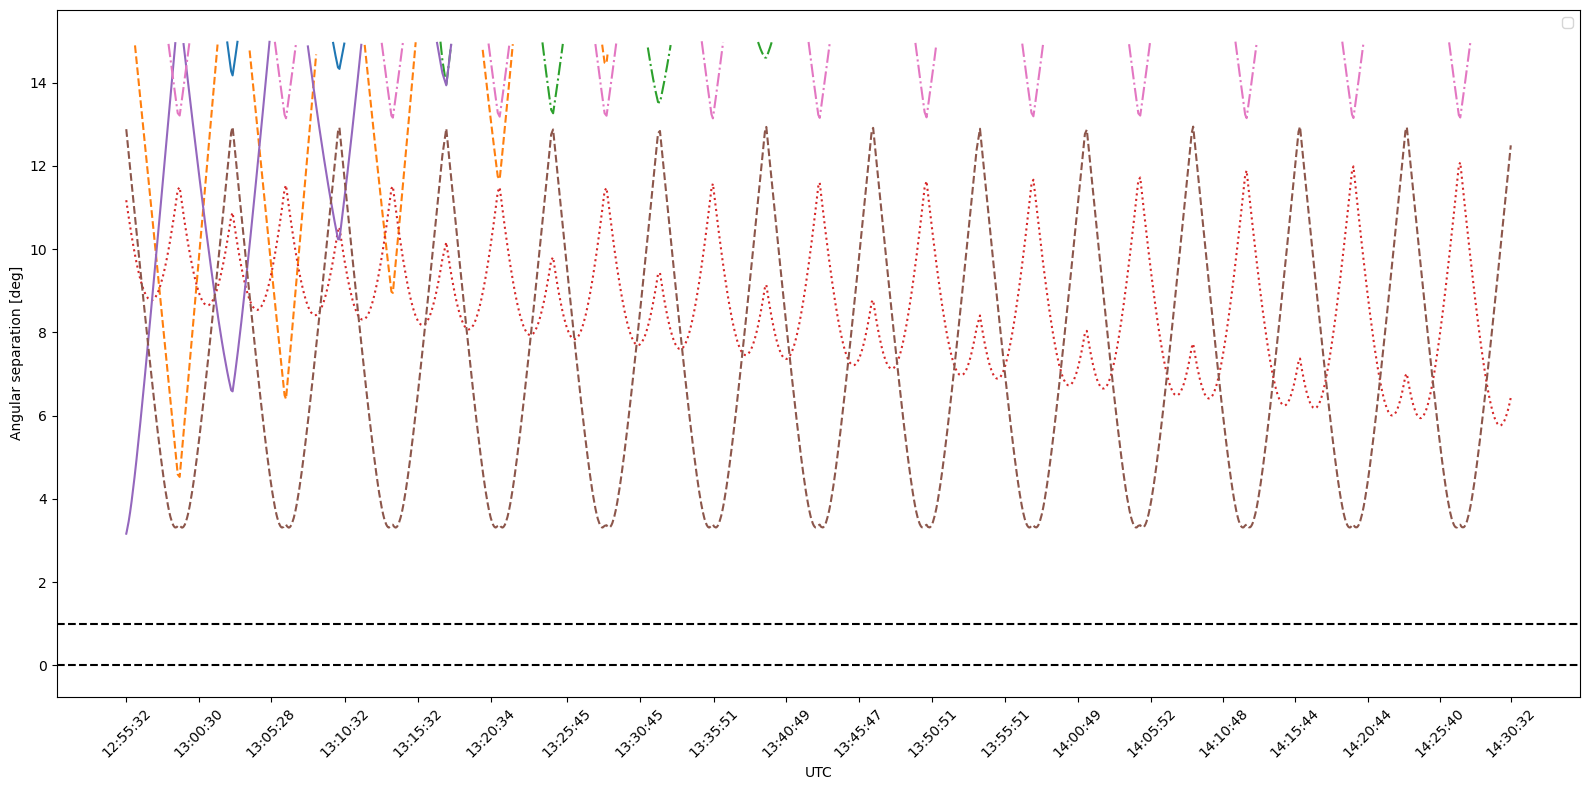

In [87]:
# plot
angles = CS.plot_angular_separations(sats3, MK_times, MK_az, MK_alt, MK_location, params)